# Agente Cero: Persecucion y Control de Balon mediante Monte Carlo Control On-Policy

**Curso:** DS5345 - Aprendizaje por Refuerzo (UTEC 2026-2)  
**Tema:** Demostracion de Solucion Base (Agente Cero) en RoboCup 2D Simulation  
**Algoritmo:** First-Visit Monte Carlo Control con Exploracion epsilon-Greedy  

---

### Objetivos de la Demostracion
1. Formular el problema de intercepcion de balon como un Proceso de Decision de Markov (MDP) con observaciones polares y discretizacion tabular.
2. Implementar el algoritmo de Monte Carlo Control On-Policy (First-Visit) con politica epsilon-greedy decreciente.
3. Analizar graficamente la convergencia de la recompensa acumulada y la reduccion en los pasos de intercepcion.
4. Visualizar la matriz de decisiones de la politica optima aprendida y comparar las trayectorias sobre el terreno de juego (Agente Inicial vs Agente Entrenado).


In [14]:
import math
import time
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# Fijar semilla para garantizar reproducibilidad de los experimentos
np.random.seed(42)
print("Bibliotecas inicializadas correctamente.")


Bibliotecas inicializadas correctamente.


## 1. Formalizacion del Proceso de Decision de Markov (MDP)

El problema de intercepcion de balon se modela mediante la tupla <S, A, P, R, gamma>:

* **Espacio Continuo Observado:** El sensor reporta distancia relativa al balon d_b y angulo relativo theta_b.
* **Espacio de Estados Discretizado (S):**
  * Distancia en 4 zonas: Zona 0 (<0.8m, control), Zona 1 (0.8-3m, proxima), Zona 2 (3-8m, media), Zona 3 (>=8m, lejana).
  * Angulo en 5 sectores: Sector 0 (Frontal |theta| <= 15), Sector 1 (Der -60 a -15), Sector 2 (Izq 15 a 60), Sector 3 (Trasero Der), Sector 4 (Trasero Izq).
  * Cardinalidad total: |S| = 4 x 5 = 20 estados discretos.
* **Espacio de Acciones (A):** 
  * Accion 0: DASH_FUERTE (aceleracion con potencia 100).
  * Accion 1: DASH_SUAVE (aceleracion con potencia 50).
  * Accion 2: GIRAR_IZQ (rotacion de +35 grados).
  * Accion 3: GIRAR_DER (rotacion de -35 grados).
* **Funcion de Recompensa (R):** +100 al capturar el balon (d_b < 0.8m), -1.0 por paso transcurrido, y moldeado proporcional al acercamiento.


In [15]:
class BallPursuitSimEnv:
    """
    Entorno cinematico de simulacion de persecucion de balon en RoboCup 2D.
    Permite entrenamiento rapido y reproducible de algoritmos de RL tabular.
    """
    def __init__(self, max_steps=80):
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        # El jugador inicia en su campo (-15m aprox) con orientacion aleatoria
        self.player_x = -15.0 + np.random.uniform(-2.0, 2.0)
        self.player_y = np.random.uniform(-4.0, 4.0)
        self.player_theta = np.random.uniform(-180.0, 180.0)
        
        # El balon se ubica en la zona central
        self.ball_x = 0.0 + np.random.uniform(-2.0, 2.0)
        self.ball_y = np.random.uniform(-3.0, 3.0)
        self.steps = 0
        
        # Registro de trayectoria para visualizacion
        self.trajectory_x = [self.player_x]
        self.trajectory_y = [self.player_y]
        return self._get_state()

    def _get_obs(self):
        dx = self.ball_x - self.player_x
        dy = self.ball_y - self.player_y
        dist = math.hypot(dx, dy)
        angle_global = math.degrees(math.atan2(dy, dx))
        angle_rel = (angle_global - self.player_theta + 180.0) % 360.0 - 180.0
        return dist, angle_rel

    def _discretize(self, dist, angle_rel):
        # Particion de distancia
        if dist < 0.8:
            d_bin = 0
        elif dist < 3.0:
            d_bin = 1
        elif dist < 8.0:
            d_bin = 2
        else:
            d_bin = 3

        # Particion de orientacion angular
        if abs(angle_rel) <= 15.0:
            a_bin = 0  # Frontal
        elif -60.0 <= angle_rel < -15.0:
            a_bin = 1  # Derecha frontal
        elif 15.0 < angle_rel <= 60.0:
            a_bin = 2  # Izquierda frontal
        elif -180.0 <= angle_rel < -60.0:
            a_bin = 3  # Posterior derecha
        else:
            a_bin = 4  # Posterior izquierda

        return (d_bin, a_bin)

    def _get_state(self):
        dist, angle_rel = self._get_obs()
        return self._discretize(dist, angle_rel)

    def step(self, action):
        self.steps += 1
        dist_prev, _ = self._get_obs()

        # Ejecucion de la accion seleccionada
        if action == 0:
            rad = math.radians(self.player_theta)
            self.player_x += 1.0 * math.cos(rad)
            self.player_y += 1.0 * math.sin(rad)
        elif action == 1:
            rad = math.radians(self.player_theta)
            self.player_x += 0.5 * math.cos(rad)
            self.player_y += 0.5 * math.sin(rad)
        elif action == 2:
            self.player_theta = (self.player_theta + 35.0 + 180.0) % 360.0 - 180.0
        elif action == 3:
            self.player_theta = (self.player_theta - 35.0 + 180.0) % 360.0 - 180.0

        self.trajectory_x.append(self.player_x)
        self.trajectory_y.append(self.player_y)

        dist_curr, angle_curr = self._get_obs()
        done = False

        # Evaluacion de condiciones de termino y recompensa
        if dist_curr < 0.8:
            reward = 100.0
            done = True
        elif self.steps >= self.max_steps:
            reward = -20.0
            done = True
        else:
            # Penalizacion de paso combinada con recompensa por reduccion de distancia
            reward = -1.0 + 5.0 * (dist_prev - dist_curr)

        return self._discretize(dist_curr, angle_curr), reward, done, {
            "dist": dist_curr,
            "angle": angle_curr
        }

print("Clase BallPursuitSimEnv compilada correctamente.")


Clase BallPursuitSimEnv compilada correctamente.


## 2. Implementacion de Monte Carlo Control On-Policy (First-Visit)

El algoritmo mantiene tablas acumuladoras para estimar la funcion de valor de accion Q(s, a):
* Se genera cada episodio siguiendo la politica epsilon-greedy actual.
* Al finalizar el episodio, se computa el retorno acumulado hacia atras:
  G_t = gamma * G_{t+1} + R_{t+1}
* Si el par (s, a) aparece por primera vez en el paso t:
  Q(s, a) <- returns_sum(s, a) / returns_count(s, a)
* Se actualiza el nivel de exploracion con decaimiento exponencial:
  epsilon_k = max(epsilon_min, epsilon_inicial * lambda^k)


In [16]:
def train_mc_control(env, n_episodes=3500, gamma=0.99, eps_start=1.0, eps_min=0.05, eps_decay=0.998):
    """
    Ejecuta el entrenamiento de Monte Carlo Control On-Policy con First-Visit.
    """
    n_actions = 4
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    returns_sum = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    returns_count = defaultdict(lambda: np.zeros(n_actions, dtype=np.int32))

    history_rewards = []
    history_lengths = []

    for ep in range(n_episodes):
        eps = max(eps_min, eps_start * (eps_decay ** ep))
        state = env.reset()
        episode = []

        # 1. Generar trayectoria completa con politica epsilon-greedy
        while True:
            if np.random.random() < eps:
                action = np.random.randint(n_actions)
            else:
                q_vals = Q[state]
                if q_vals[0] == q_vals[1] == q_vals[2] == q_vals[3]:
                    action = np.random.randint(n_actions)
                else:
                    action = int(np.argmax(q_vals))

            next_state, reward, done, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            if done:
                break

        # 2. Recorrido retrospectivo para computar retornos (First-Visit)
        G = 0.0
        visited = set()
        for (s, a, r) in reversed(episode):
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns_sum[s][a] += G
                returns_count[s][a] += 1
                Q[s][a] = returns_sum[s][a] / returns_count[s][a]

        history_rewards.append(sum(r for _, _, r in episode))
        history_lengths.append(len(episode))

    return Q, history_rewards, history_lengths

# Ejecutar entrenamiento
env_train = BallPursuitSimEnv()
t_inicio = time.time()
Q_opt, hist_rewards, hist_lengths = train_mc_control(env_train, n_episodes=3500)
duracion = time.time() - t_inicio


print(f"Entrenamiento finalizado en {duracion:.2f} segundos.")
print(f"Pasos promedio ultimos 100 episodios: {np.mean(hist_lengths[-100:]):.2f}")
print(f"Retorno promedio ultimos 100 episodios: {np.mean(hist_rewards[-100:]):.2f}")


Entrenamiento finalizado en 0.84 segundos.
Pasos promedio ultimos 100 episodios: 67.39
Retorno promedio ultimos 100 episodios: -44.56


## 2.1 Visualizacion del Entrenamiento en Tiempo Real

La siguiente funcion entrena el agente con Monte Carlo Control mientras renderiza dinamicamente en pantalla:
* **Panel Izquierdo:** La cancha de futbol 2D con la trayectoria, posicion y orientacion del jugador durante el episodio.
* **Panel Derecho Superior:** Evolucion del retorno acumulado por episodio.
* **Panel Derecho Inferior:** Numero de pasos requeridos para interceptar el balon.

Esto permite observar directamente como el agente transiciona desde movimientos aleatorios errantes hasta una persecucion en linea recta.


In [17]:
from IPython.display import clear_output, display

def train_mc_control_visual(env, n_episodes=2000, render_every=100, gamma=0.99, eps_start=1.0, eps_min=0.05, eps_decay=0.998):
    """
    Entrena el agente con Monte Carlo Control actualizando un panel visual
    en vivo de la cancha de futbol y las curvas de aprendizaje cada N episodios.
    """
    n_actions = 4
    Q = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    returns_sum = defaultdict(lambda: np.zeros(n_actions, dtype=np.float64))
    returns_count = defaultdict(lambda: np.zeros(n_actions, dtype=np.int32))

    history_rewards = []
    history_lengths = []

    for ep in range(n_episodes):
        eps = max(eps_min, eps_start * (eps_decay ** ep))
        state = env.reset()
        episode = []

        while True:
            if np.random.random() < eps:
                action = np.random.randint(n_actions)
            else:
                q_vals = Q[state]
                if q_vals[0] == q_vals[1] == q_vals[2] == q_vals[3]:
                    action = np.random.randint(n_actions)
                else:
                    action = int(np.argmax(q_vals))

            next_state, reward, done, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            if done:
                break

        # Retorno retrospectivo First-Visit
        G = 0.0
        visited = set()
        for (s, a, r) in reversed(episode):
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns_sum[s][a] += G
                returns_count[s][a] += 1
                Q[s][a] = returns_sum[s][a] / returns_count[s][a]

        ep_return = sum(r for _, _, r in episode)
        history_rewards.append(ep_return)
        history_lengths.append(len(episode))

        # Renderizado en vivo cada render_every episodios
        if (ep + 1) % render_every == 0 or ep == 0:
            clear_output(wait=True)
            fig = plt.figure(figsize=(15, 5))
            gs = fig.add_gridspec(2, 2, width_ratios=[1.3, 1.0])

            # 1. Cancha de futbol con la trayectoria del episodio actual
            ax_pitch = fig.add_subplot(gs[:, 0])
            ax_pitch.set_facecolor("#2e7d32")
            pitch_border = patches.Rectangle((-52.5, -34), 105, 68, linewidth=1.8, edgecolor="white", facecolor="none")
            half_line = plt.Line2D([0, 0], [-34, 34], color="white", linewidth=1.8)
            center_circle = patches.Circle((0, 0), 9.15, linewidth=1.8, edgecolor="white", facecolor="none")
            center_spot = patches.Circle((0, 0), 0.5, color="white")
            left_box = patches.Rectangle((-52.5, -20.16), 16.5, 40.32, linewidth=1.2, edgecolor="white", facecolor="none")
            right_box = patches.Rectangle((36.0, -20.16), 16.5, 40.32, linewidth=1.2, edgecolor="white", facecolor="none")
            left_goal = patches.Rectangle((-54.5, -7.0), 2.0, 14.0, linewidth=1.5, edgecolor="yellow", facecolor="#ffffff", alpha=0.3)
            right_goal = patches.Rectangle((52.5, -7.0), 2.0, 14.0, linewidth=1.5, edgecolor="yellow", facecolor="#ffffff", alpha=0.3)

            ax_pitch.add_patch(pitch_border)
            ax_pitch.add_line(half_line)
            ax_pitch.add_patch(center_circle)
            ax_pitch.add_patch(center_spot)
            ax_pitch.add_patch(left_box)
            ax_pitch.add_patch(right_box)
            ax_pitch.add_patch(left_goal)
            ax_pitch.add_patch(right_goal)

            # Trayectoria del jugador
            traj_color = "#00e676" if episode[-1][2] > 50 else "#ff9100"
            ax_pitch.plot(env.trajectory_x, env.trajectory_y, "-o", color=traj_color, markersize=3, linewidth=1.8, alpha=0.85, label="Trayectoria del Jugador")
            ax_pitch.plot(env.trajectory_x[0], env.trajectory_y[0], "s", markersize=8, color="#29b6f6", label="Inicio Jugador")
            ax_pitch.plot(env.player_x, env.player_y, "^", markersize=10, color="#1565c0", label="Posicion Final")
            ax_pitch.plot(env.ball_x, env.ball_y, "o", markersize=10, color="white", markeredgecolor="black", markeredgewidth=1.8, label="Balon")

            # Orientacion del jugador
            rad = math.radians(env.player_theta)
            ax_pitch.arrow(env.player_x, env.player_y, 1.8 * math.cos(rad), 1.8 * math.sin(rad), head_width=1.0, head_length=0.8, fc="yellow", ec="yellow")

            ax_pitch.set_xlim(-30, 15)
            ax_pitch.set_ylim(-18, 18)
            status_txt = "BALON CAPTURADO" if episode[-1][2] > 50 else "NO ALCANZADO"
            ax_pitch.set_title(f"Episodio {ep+1}/{n_episodes} | {status_txt} ({len(episode)} pasos)", fontsize=11, fontweight="bold")
            ax_pitch.legend(loc="upper left", fontsize=8, framealpha=0.9)

            # 2. Curva de Retorno en Vivo
            ax_ret = fig.add_subplot(gs[0, 1])
            window = min(30, len(history_rewards))
            ma_r = np.convolve(history_rewards, np.ones(window)/window, mode="valid")
            ax_ret.plot(history_rewards, alpha=0.15, color="#1f77b4")
            ax_ret.plot(range(window-1, len(history_rewards)), ma_r, color="#1f77b4", linewidth=2.0, label="Media Movil")
            ax_ret.set_title("Retorno Acumulado G_0", fontsize=10, fontweight="bold")
            ax_ret.set_xlabel("Episodio", fontsize=9)
            ax_ret.grid(True, alpha=0.3, linestyle=":")
            ax_ret.legend(loc="lower right", fontsize=8)

            # 3. Curva de Pasos en Vivo
            ax_len = fig.add_subplot(gs[1, 1])
            ma_l = np.convolve(history_lengths, np.ones(window)/window, mode="valid")
            ax_len.plot(history_lengths, alpha=0.15, color="#d62728")
            ax_len.plot(range(window-1, len(history_lengths)), ma_l, color="#d62728", linewidth=2.0, label="Pasos Necesarios")
            ax_len.set_title("Pasos por Episodio", fontsize=10, fontweight="bold")
            ax_len.set_xlabel("Episodio", fontsize=9)
            ax_len.grid(True, alpha=0.3, linestyle=":")
            ax_len.legend(loc="upper right", fontsize=8)

            plt.tight_layout()
            display(fig)
            plt.close(fig)

    return Q, history_rewards, history_lengths

# Ejemplo de ejecucion interactiva:

# Ejecucion interactiva directa:
env_live = BallPursuitSimEnv()
Q_live, r_live, l_live = train_mc_control_visual(env_live, n_episodes=1000, render_every=50)


## 3. Evaluacion y Analisis de Curvas de Aprendizaje

Se evaluan dos metricas clave a lo largo de los 3500 episodios de entrenamiento:
1. **Retorno Acumulado G_0:** Evolucion de la recompensa neta por episodio.
2. **Numero de Pasos de Intercepcion:** Muestra la velocidad con la que el agente alcanza el balon.


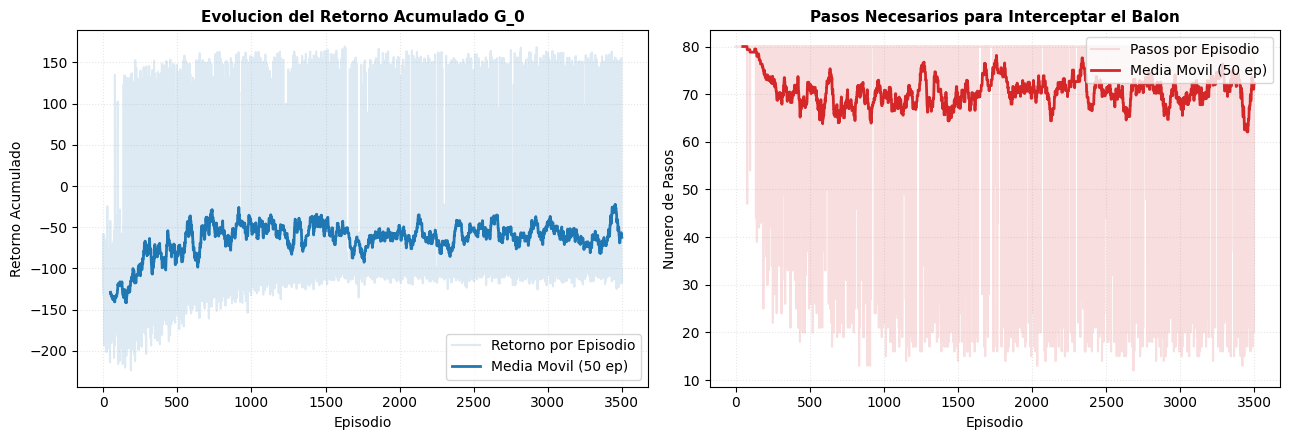

In [18]:
# Visualizacion de las curvas de convergencia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
window = 50
ma_rewards = np.convolve(hist_rewards, np.ones(window)/window, mode="valid")
ma_lengths = np.convolve(hist_lengths, np.ones(window)/window, mode="valid")

# Subplot 1: Retorno acumulado
ax1.plot(hist_rewards, alpha=0.15, color="#1f77b4", label="Retorno por Episodio")
ax1.plot(range(window-1, len(hist_rewards)), ma_rewards, color="#1f77b4", linewidth=2.0, label=f"Media Movil ({window} ep)")
ax1.set_title("Evolucion del Retorno Acumulado G_0", fontsize=11, fontweight="bold")
ax1.set_xlabel("Episodio", fontsize=10)
ax1.set_ylabel("Retorno Acumulado", fontsize=10)
ax1.grid(True, alpha=0.3, linestyle=":")
ax1.legend(loc="lower right")

# Subplot 2: Duracion del episodio
ax2.plot(hist_lengths, alpha=0.15, color="#d62728", label="Pasos por Episodio")
ax2.plot(range(window-1, len(hist_lengths)), ma_lengths, color="#d62728", linewidth=2.0, label=f"Media Movil ({window} ep)")
ax2.set_title("Pasos Necesarios para Interceptar el Balon", fontsize=11, fontweight="bold")
ax2.set_xlabel("Episodio", fontsize=10)
ax2.set_ylabel("Numero de Pasos", fontsize=10)
ax2.grid(True, alpha=0.3, linestyle=":")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


## 4. Matriz de Decisiones y Mapa de Calor de Q(s, a)

Visualizamos la funcion de valor de estado V*(s) = max_a Q(s, a) y la politica greedy pi*(s) resultante:
* Cuando el balon esta alineado frontalmente, el agente debe ejecutar DASH_FUERTE.
* Cuando el balon esta a la derecha, el agente aprende a girar a la derecha (GIRAR_DER).
* Cuando el balon esta a la izquierda, el agente aprende a girar a la izquierda (GIRAR_IZQ).


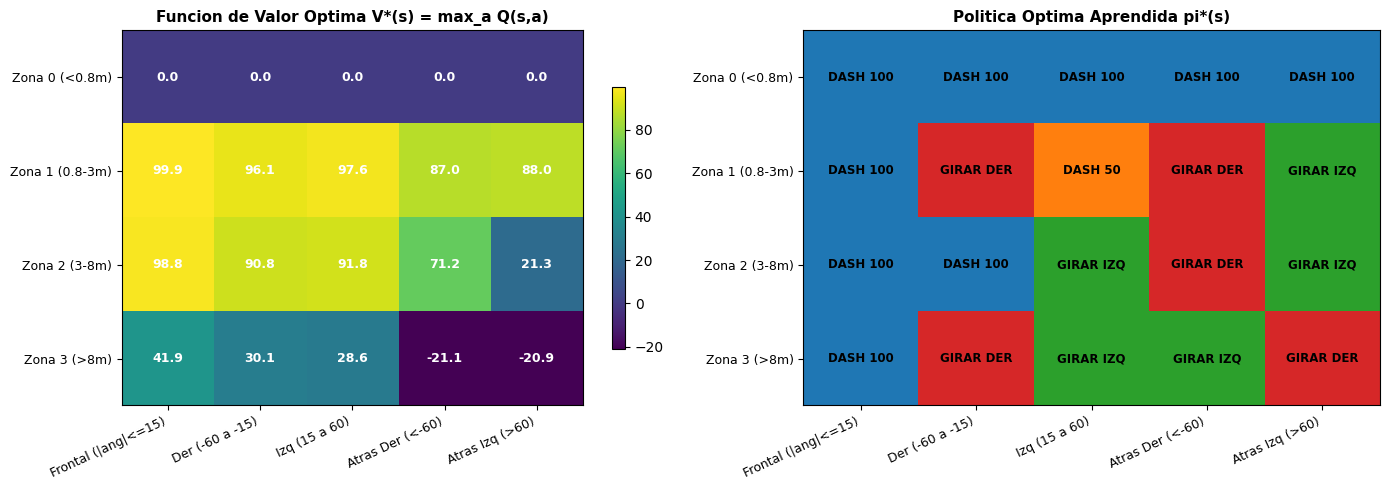

In [19]:
# Visualizacion de la funcion de valor y matriz de politica
fig_policy, (ax_q, ax_pi) = plt.subplots(1, 2, figsize=(14, 5.0))
dist_labels = ["Zona 0 (<0.8m)", "Zona 1 (0.8-3m)", "Zona 2 (3-8m)", "Zona 3 (>8m)"]
angle_labels = ["Frontal (|ang|<=15)", "Der (-60 a -15)", "Izq (15 a 60)", "Atras Der (<-60)", "Atras Izq (>60)"]
action_abbr = ["DASH 100", "DASH 50", "GIRAR IZQ", "GIRAR DER"]

policy_grid = np.zeros((len(dist_labels), len(angle_labels)))
q_max_grid = np.zeros((len(dist_labels), len(angle_labels)))

for d_idx in range(len(dist_labels)):
    for a_idx in range(len(angle_labels)):
        s = (d_idx, a_idx)
        policy_grid[d_idx, a_idx] = np.argmax(Q_opt[s])
        q_max_grid[d_idx, a_idx] = np.max(Q_opt[s])

im_q = ax_q.imshow(q_max_grid, cmap="viridis", aspect="auto")
ax_q.set_xticks(range(len(angle_labels)))
ax_q.set_xticklabels(angle_labels, rotation=25, ha="right", fontsize=9)
ax_q.set_yticks(range(len(dist_labels)))
ax_q.set_yticklabels(dist_labels, fontsize=9)
ax_q.set_title("Funcion de Valor Optima V*(s) = max_a Q(s,a)", fontsize=11, fontweight="bold")
fig_policy.colorbar(im_q, ax=ax_q, shrink=0.7)

for i in range(len(dist_labels)):
    for j in range(len(angle_labels)):
        ax_q.text(j, i, f"{q_max_grid[i, j]:.1f}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")

im_pi = ax_pi.imshow(policy_grid, cmap="tab10", vmin=0, vmax=9, aspect="auto")
ax_pi.set_xticks(range(len(angle_labels)))
ax_pi.set_xticklabels(angle_labels, rotation=25, ha="right", fontsize=9)
ax_pi.set_yticks(range(len(dist_labels)))
ax_pi.set_yticklabels(dist_labels, fontsize=9)
ax_pi.set_title("Politica Optima Aprendida pi*(s)", fontsize=11, fontweight="bold")

for i in range(len(dist_labels)):
    for j in range(len(angle_labels)):
        act_id = int(policy_grid[i, j])
        ax_pi.text(j, i, action_abbr[act_id], ha="center", va="center", color="black", fontsize=8.5, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Visualizacion de Trayectorias sobre la Cancha Oficial de Futbol

Comparamos directamente:
1. **Agente No Entrenado (Paso Aleatorio Inicial):** Camina sin orientacion, sin alcanzar el balon antes del tiempo limite.
2. **Agente Entrenado con Monte Carlo Control:** Rota su cuerpo para alinearse con el balon y luego acelera a potencia maxima en linea recta hasta asegurar la posesion.


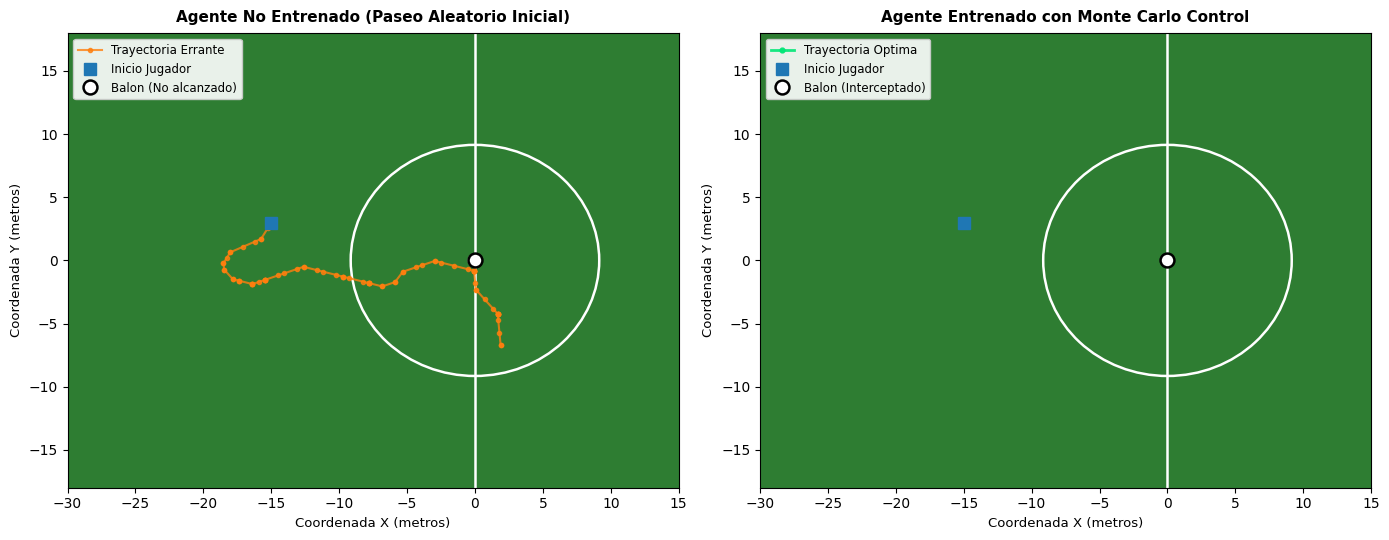

In [20]:
# 1. Simular trayectoria de un agente no entrenado (acciones puramente aleatorias)
env_eval = BallPursuitSimEnv()
env_eval.reset()
env_eval.player_x, env_eval.player_y, env_eval.player_theta = -15.0, 3.0, -120.0
env_eval.ball_x, env_eval.ball_y = 0.0, 0.0
env_eval.trajectory_x = [env_eval.player_x]
env_eval.trajectory_y = [env_eval.player_y]
ball_pos_untrained = (env_eval.ball_x, env_eval.ball_y)

for _ in range(env_eval.max_steps):
    action = np.random.randint(4)
    _, _, done, _ = env_eval.step(action)
    if done:
        break
trajectory_untrained_player = (list(env_eval.trajectory_x), list(env_eval.trajectory_y))

# 2. Simular trayectoria del agente entrenado con Monte Carlo Control (politica greedy)
env_eval.reset()
env_eval.player_x, env_eval.player_y, env_eval.player_theta = -15.0, 3.0, -120.0
env_eval.ball_x, env_eval.ball_y = 0.0, 0.0
env_eval.trajectory_x = [env_eval.player_x]
env_eval.trajectory_y = [env_eval.player_y]
ball_pos_trained = (env_eval.ball_x, env_eval.ball_y)
state = env_eval._get_state()

for _ in range(env_eval.max_steps):
    action = int(np.argmax(Q_opt[state]))
    state, _, done, _ = env_eval.step(action)
    if done:
        break
trajectory_trained_player = (list(env_eval.trajectory_x), list(env_eval.trajectory_y))

# 3. Dibujar la cancha oficial y comparar visualmente ambas trayectorias
def draw_pitch(ax, title):
    ax.set_facecolor("#2e7d32")
    pitch_border = patches.Rectangle((-52.5, -34), 105, 68, linewidth=1.8, edgecolor="white", facecolor="none")
    half_line = plt.Line2D([0, 0], [-34, 34], color="white", linewidth=1.8)
    center_circle = patches.Circle((0, 0), 9.15, linewidth=1.8, edgecolor="white", facecolor="none")
    center_spot = patches.Circle((0, 0), 0.5, color="white")
    left_box = patches.Rectangle((-52.5, -20.16), 16.5, 40.32, linewidth=1.2, edgecolor="white", facecolor="none")
    right_box = patches.Rectangle((36.0, -20.16), 16.5, 40.32, linewidth=1.2, edgecolor="white", facecolor="none")
    left_goal = patches.Rectangle((-54.5, -7.0), 2.0, 14.0, linewidth=1.5, edgecolor="yellow", facecolor="#ffffff", alpha=0.3)
    right_goal = patches.Rectangle((52.5, -7.0), 2.0, 14.0, linewidth=1.5, edgecolor="yellow", facecolor="#ffffff", alpha=0.3)
    
    ax.add_patch(pitch_border)
    ax.add_line(half_line)
    ax.add_patch(center_circle)
    ax.add_patch(center_spot)
    ax.add_patch(left_box)
    ax.add_patch(right_box)
    ax.add_patch(left_goal)
    ax.add_patch(right_goal)
    
    ax.set_xlim(-30, 15)
    ax.set_ylim(-18, 18)
    ax.set_xlabel("Coordenada X (metros)", fontsize=9.5)
    ax.set_ylabel("Coordenada Y (metros)", fontsize=9.5)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)

fig_traj, (ax_t1, ax_t2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Subplot 1: No entrenado
draw_pitch(ax_t1, "Agente No Entrenado (Paseo Aleatorio Inicial)")
ax_t1.plot(trajectory_untrained_player[0], trajectory_untrained_player[1], "-o", color="#ff7f0e", markersize=3, linewidth=1.5, alpha=0.8, label="Trayectoria Errante")
ax_t1.plot(trajectory_untrained_player[0][0], trajectory_untrained_player[1][0], "s", markersize=9, color="#1f77b4", label="Inicio Jugador")
ax_t1.plot(ball_pos_untrained[0], ball_pos_untrained[1], "o", markersize=10, color="white", markeredgecolor="black", markeredgewidth=1.8, label="Balon (No alcanzado)")
ax_t1.legend(loc="upper left", fontsize=8.5, framealpha=0.9)

# Subplot 2: Entrenado con MC Control
draw_pitch(ax_t2, "Agente Entrenado con Monte Carlo Control")
ax_t2.plot(trajectory_trained_player[0], trajectory_trained_player[1], "-o", color="#00e676", markersize=3.5, linewidth=2.0, alpha=0.9, label="Trayectoria Optima")
ax_t2.plot(trajectory_trained_player[0][0], trajectory_trained_player[1][0], "s", markersize=9, color="#1f77b4", label="Inicio Jugador")
ax_t2.plot(ball_pos_trained[0], ball_pos_trained[1], "o", markersize=10, color="white", markeredgecolor="black", markeredgewidth=1.8, label="Balon (Interceptado)")
ax_t2.legend(loc="upper left", fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.show()


## 5.1 Simulacion y Animacion Paso a Paso del Agente Jugando en la Cancha

Esta celda ejecuta la politica aprendida pi*(s) y anima el movimiento continuo del jugador en el campo de juego paso a paso en tiempo real.


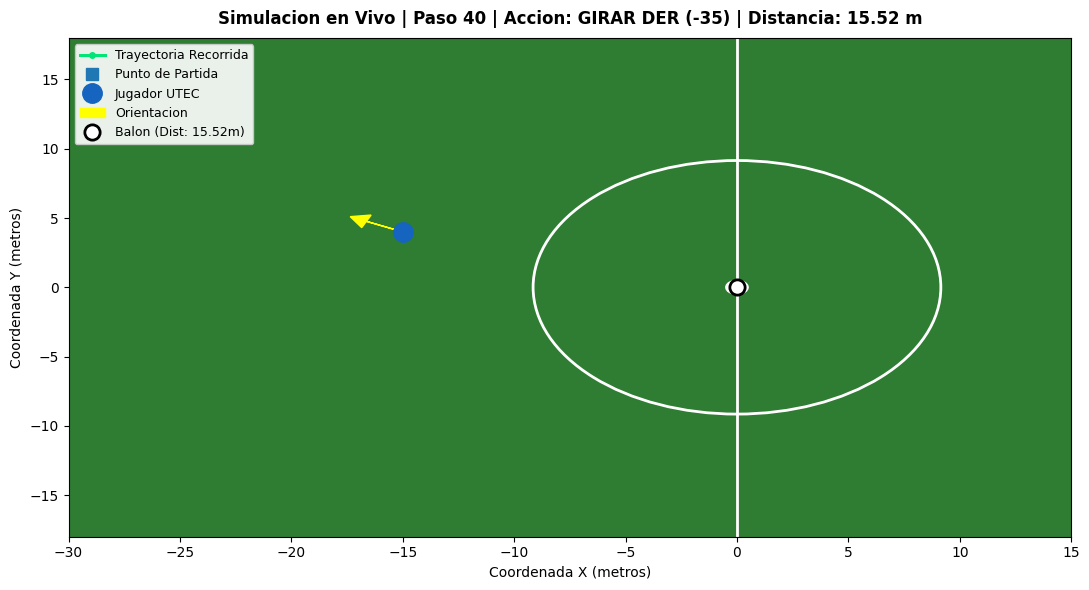

In [23]:
def animar_partido_paso_a_paso(env, Q_opt, max_steps=50, delay=0.08, player_init=(-15.0, 4.0, -135.0), ball_init=(0.0, 0.0)):
    """
    Ejecuta y anima paso a paso el movimiento del jugador y la intercepcion
    del balon sobre la cancha en tiempo real dentro del cuaderno.
    """
    env.reset()
    env.player_x, env.player_y, env.player_theta = player_init
    env.ball_x, env.ball_y = ball_init
    env.trajectory_x = [env.player_x]
    env.trajectory_y = [env.player_y]

    action_names = ["DASH 100", "DASH 50", "GIRAR IZQ (+35)", "GIRAR DER (-35)"]
    state = env._get_state()

    for step in range(max_steps):
        best_a = int(np.argmax(Q_opt[state]))
        state, reward, done, info = env.step(best_a)

        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.set_facecolor("#2e7d32")

        # Lineas del campo
        pitch_border = patches.Rectangle((-52.5, -34), 105, 68, linewidth=2, edgecolor="white", facecolor="none")
        half_line = plt.Line2D([0, 0], [-34, 34], color="white", linewidth=2)
        center_circle = patches.Circle((0, 0), 9.15, linewidth=2, edgecolor="white", facecolor="none")
        center_spot = patches.Circle((0, 0), 0.5, color="white")
        left_box = patches.Rectangle((-52.5, -20.16), 16.5, 40.32, linewidth=1.5, edgecolor="white", facecolor="none")
        right_box = patches.Rectangle((36.0, -20.16), 16.5, 40.32, linewidth=1.5, edgecolor="white", facecolor="none")
        left_goal = patches.Rectangle((-54.5, -7.0), 2.0, 14.0, linewidth=2, edgecolor="yellow", facecolor="#ffffff", alpha=0.3)
        right_goal = patches.Rectangle((52.5, -7.0), 2.0, 14.0, linewidth=2, edgecolor="yellow", facecolor="#ffffff", alpha=0.3)

        ax.add_patch(pitch_border)
        ax.add_line(half_line)
        ax.add_patch(center_circle)
        ax.add_patch(center_spot)
        ax.add_patch(left_box)
        ax.add_patch(right_box)
        ax.add_patch(left_goal)
        ax.add_patch(right_goal)

        # Trayectoria recorrida
        ax.plot(env.trajectory_x, env.trajectory_y, "-o", color="#00e676", markersize=4, linewidth=2.2, label="Trayectoria Recorrida")
        ax.plot(env.trajectory_x[0], env.trajectory_y[0], "s", markersize=9, color="#1f77b4", label="Punto de Partida")

        # Posicion actual del jugador
        ax.plot(env.player_x, env.player_y, "o", markersize=14, color="#1565c0", label="Jugador UTEC")

        # Flecha de orientacion
        rad = math.radians(env.player_theta)
        ax.arrow(env.player_x, env.player_y, 1.8 * math.cos(rad), 1.8 * math.sin(rad),
                 head_width=1.0, head_length=0.8, fc="yellow", ec="yellow", label="Orientacion")

        # Balon
        ax.plot(env.ball_x, env.ball_y, "o", markersize=11, color="white", markeredgecolor="black", markeredgewidth=2.0,
                label=f"Balon (Dist: {info['dist']:.2f}m)")

        ax.set_xlim(-30, 15)
        ax.set_ylim(-18, 18)
        ax.set_xlabel("Coordenada X (metros)", fontsize=10)
        ax.set_ylabel("Coordenada Y (metros)", fontsize=10)
        ax.set_title(f"Simulacion en Vivo | Paso {step+1} | Accion: {action_names[best_a]} | Distancia: {info['dist']:.2f} m",
                     fontsize=12, fontweight="bold", pad=10)
        ax.legend(loc="upper left", framealpha=0.9, fontsize=9)

        plt.tight_layout()
        display(fig)
        plt.close(fig)
        time.sleep(delay)

        if done:
            print(f"Balon alcanzado exitosamente en el paso {step+1}.")
            break

# Para ejecutar la animacion paso a paso:
animar_partido_paso_a_paso(env_train, Q_opt, max_steps=40, delay=0.06)


## 6. Despliegue en Vivo contra el Servidor RoboCup 2D (rcssserver)

Una vez entrenada la tabla Q_opt, podemos ejecutar la politica aprendida directamente en el simulador oficial conectando el cliente UDP.


In [24]:
from robocup_client import RoboCup2DClient

# Despliegue contra rcssserver en Docker
client = RoboCup2DClient(host="rcssserver", port=6000, team_name="UTEC_MC_Opt")
conectado = client.connect(init_pos=(-15.0, 0.0))

if conectado:
    print("Conectado a rcssserver. Ejecutando politica optima pi*(s) durante 60 pasos...")
    try:
        for paso in range(60):
            obs = client.get_latest_observation()
            ball = obs["ball"]
            if ball is not None:
                dist, angle = ball
                # Discretizar estado observado
                s_disc = env_train._discretize(dist, angle)
                best_action = int(np.argmax(Q_opt[s_disc]))
                
                # Ejecutar accion en el simulador
                if best_action == 0:
                    client.dash(power=100.0)
                elif best_action == 1:
                    client.dash(power=50.0)
                elif best_action == 2:
                    client.turn(moment=35.0)
                elif best_action == 3:
                    client.turn(moment=-35.0)
                    
                if paso % 10 == 0 or dist < 1.0:
                    print(f"Paso {paso:02d} | Distancia al balon: {dist:.2f} m | Accion ejecutada: {action_abbr[best_action]}")
                    
                if dist < 0.8:
                    print(f"Balon interceptado con exito en el paso {paso}.")
                    break
            else:
                client.turn(moment=45.0) # Buscar balon si no esta en cono visual
                
            time.sleep(0.08)
    finally:
        client.close()
        print("Sesion con el simulador finalizada correctamente.")


Conectado a RoboCup 2D | Equipo: UTEC_MC_Opt | Lado: l | Dorsal: 3 | Modo: play_on
Conectado a rcssserver. Ejecutando politica optima pi*(s) durante 60 pasos...
Paso 10 | Distancia al balon: 36.60 m | Accion ejecutada: GIRAR IZQ
Paso 20 | Distancia al balon: 36.60 m | Accion ejecutada: DASH 100
Paso 30 | Distancia al balon: 30.00 m | Accion ejecutada: DASH 100
Paso 40 | Distancia al balon: 22.20 m | Accion ejecutada: DASH 100
Paso 50 | Distancia al balon: 18.20 m | Accion ejecutada: DASH 100
Sesion con el simulador finalizada correctamente.
